# Notebook 05: Detector Experiments

This notebook compares the frozen S8-CFD baseline with Experiment 1, the standard IoU localization-loss ablation. It is an artifact-only analysis: it reads committed experiment outputs, regenerates comparison figures, and does not retrain, run inference, access W&B, load checkpoints, or access the test split.


## 1. Controlled Experiment Definition

The experimental question is whether adding a standard IoU localization term improves strict localization for the from-scratch S8-CFD detector.

Baseline objective:

```text
L = L_obj + 5 L_center + 2 L_size
```

Experiment 1 objective:

```text
L = L_obj + 5 L_center + 2 L_size + 1.0 L_iou
```

Everything else was held fixed: S8-CFD architecture, 960x544 input, stride 8, 20 epochs, batch size 2, learning rate 0.001, weight decay 0.0001, fixed LR, seed 42, and the same train/validation split. The predetermined model-selection metric remains validation `mAP50-95`.


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPERIMENT_ROOT = PROJECT_ROOT / "reports" / "experiments"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = {
    "baseline": {
        "label": "Baseline",
        "run_name": "baseline-s8-cfd-960-s8",
        "objective": "L_obj + 5 L_center + 2 L_size",
        "iou_loss_weight": 0.0,
        "threshold_source": "refined",
    },
    "iou1": {
        "label": "IoU loss lambda=1",
        "run_name": "ablation-iou1-s8-cfd-960-s8",
        "objective": "L_obj + 5 L_center + 2 L_size + 1.0 L_iou",
        "iou_loss_weight": 1.0,
        "threshold_source": "validation sweep",
    },
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

def save_figure(fig: plt.Figure, name: str) -> None:
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved {png_path.relative_to(PROJECT_ROOT)} and {pdf_path.relative_to(PROJECT_ROOT)}")

def best_threshold_row(df: pd.DataFrame) -> dict[str, float]:
    return df.sort_values(["f1", "precision", "recall"], ascending=False).iloc[0].to_dict()

required_paths = []
for spec in EXPERIMENTS.values():
    exp_dir = EXPERIMENT_ROOT / spec["run_name"]
    required_paths.extend([
        exp_dir / "config.json",
        exp_dir / "training_history.csv",
        exp_dir / "metrics" / "best_checkpoint.json",
        exp_dir / "metrics" / "val_inference_metrics.json",
        exp_dir / "threshold" / "threshold_analysis.csv",
    ])
required_paths.append(EXPERIMENT_ROOT / EXPERIMENTS["baseline"]["run_name"] / "threshold" / "broad" / "threshold_analysis.csv")

missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required committed artifacts: " + ", ".join(str(path) for path in missing))

artifacts = {}
for key, spec in EXPERIMENTS.items():
    exp_dir = EXPERIMENT_ROOT / spec["run_name"]
    artifacts[key] = {
        "dir": exp_dir,
        "config": load_json(exp_dir / "config.json"),
        "history": pd.read_csv(exp_dir / "training_history.csv"),
        "best_checkpoint": load_json(exp_dir / "metrics" / "best_checkpoint.json"),
        "val_metrics": load_json(exp_dir / "metrics" / "val_inference_metrics.json"),
        "threshold": pd.read_csv(exp_dir / "threshold" / "threshold_analysis.csv"),
    }
artifacts["baseline"]["threshold_broad"] = pd.read_csv(
    EXPERIMENT_ROOT / EXPERIMENTS["baseline"]["run_name"] / "threshold" / "broad" / "threshold_analysis.csv"
)

print("Loaded artifact-only experiment comparison inputs.")


Loaded artifact-only experiment comparison inputs.


In [2]:
artifact_inventory = []
for key, spec in EXPERIMENTS.items():
    exp_dir = EXPERIMENT_ROOT / spec["run_name"]
    for path in sorted(exp_dir.rglob("*")):
        if path.is_file():
            artifact_inventory.append({
                "experiment": spec["label"],
                "relative_path": str(path.relative_to(PROJECT_ROOT)),
                "size_kib": path.stat().st_size / 1024,
            })
artifact_inventory_df = pd.DataFrame(artifact_inventory)
display(artifact_inventory_df)


,experiment,relative_path,size_kib
0,Baseline,reports/experiments/baseline-s8-cfd-960-s8/con...,2.161133
1,Baseline,reports/experiments/baseline-s8-cfd-960-s8/met...,0.160156
2,Baseline,reports/experiments/baseline-s8-cfd-960-s8/met...,5.781250
3,Baseline,reports/experiments/baseline-s8-cfd-960-s8/met...,1.409180
4,Baseline,reports/experiments/baseline-s8-cfd-960-s8/qua...,1132.060547
5,Baseline,reports/experiments/baseline-s8-cfd-960-s8/qua...,1183.985352
6,Baseline,reports/experiments/baseline-s8-cfd-960-s8/qua...,1429.055664
7,Baseline,reports/experiments/baseline-s8-cfd-960-s8/qua...,1558.584961
8,Baseline,reports/experiments/baseline-s8-cfd-960-s8/qua...,865.523438
9,Baseline,reports/experiments/baseline-s8-cfd-960-s8/qua...,942.643555


## 2. Configuration Parity

The comparison below is restricted to the intended controlled difference: the IoU localization-loss weight. The baseline artifacts predate the explicit `lambda_iou` field, so a missing IoU weight is interpreted as `0.0` for reporting.


In [3]:
def loss_weight(config: dict, key: str, default: float = 0.0) -> float:
    loss_config = config.get("loss_config", {}) or {}
    detector_config = config.get("detector_config", {}) or {}
    return float(loss_config.get(key, detector_config.get(key, default)))

config_rows = []
for key, spec in EXPERIMENTS.items():
    cfg = artifacts[key]["config"]
    detector = cfg.get("detector_config", {})
    config_rows.append({
        "experiment": spec["label"],
        "run_name": cfg["run_name"],
        "objective": spec["objective"],
        "input_resolution": f'{detector.get("input_width")}x{detector.get("input_height")}',
        "stride": detector.get("stride"),
        "epochs": cfg.get("train_epochs"),
        "batch_size": cfg.get("batch_size"),
        "learning_rate": cfg.get("learning_rate"),
        "weight_decay": cfg.get("weight_decay"),
        "lr_scheduler": cfg.get("lr_scheduler"),
        "seed": cfg.get("seed"),
        "lambda_obj": loss_weight(cfg, "lambda_obj", 1.0),
        "lambda_center": loss_weight(cfg, "lambda_center", 5.0),
        "lambda_size": loss_weight(cfg, "lambda_size", 2.0),
        "lambda_iou": loss_weight(cfg, "lambda_iou", 0.0),
        "selected_device": cfg.get("selected_device"),
    })
config_df = pd.DataFrame(config_rows)
display(config_df)

controlled_columns = ["input_resolution", "stride", "epochs", "batch_size", "learning_rate", "weight_decay", "lr_scheduler", "seed", "lambda_obj", "lambda_center", "lambda_size"]
for column in controlled_columns:
    assert config_df[column].nunique(dropna=False) == 1, f"Unexpected uncontrolled config difference: {column}"
assert math.isclose(float(config_df.loc[config_df["experiment"] == "Baseline", "lambda_iou"].iloc[0]), 0.0, abs_tol=1e-12)
assert math.isclose(float(config_df.loc[config_df["experiment"] == "IoU loss lambda=1", "lambda_iou"].iloc[0]), 1.0, abs_tol=1e-12)


,experiment,run_name,objective,input_resolution,stride,epochs,batch_size,learning_rate,weight_decay,lr_scheduler,seed,lambda_obj,lambda_center,lambda_size,lambda_iou,selected_device
0,Baseline,baseline-s8-cfd-960-s8,L_obj + 5 L_center + 2 L_size,960x544,8,20,2,0.001,0.0001,none,42,1.0,5.0,2.0,0.0,cuda
1,IoU loss lambda=1,ablation-iou1-s8-cfd-960-s8,L_obj + 5 L_center + 2 L_size + 1.0 L_iou,960x544,8,20,2,0.001,0.0001,none,42,1.0,5.0,2.0,1.0,cuda


## 3. Metric Checks

The notebook derives the exact metric values from the committed experiment artifacts and asserts the frozen reference values. Ranked AP metrics come from `metrics/val_inference_metrics.json`; operating-threshold precision/recall/F1 comes from the validation threshold sweep best-F1 row.


In [4]:
metric_rows = []
for key, spec in EXPERIMENTS.items():
    val = artifacts[key]["val_metrics"]
    best_ckpt = artifacts[key]["best_checkpoint"]
    threshold_best = best_threshold_row(artifacts[key]["threshold"])
    metric_rows.append({
        "experiment": spec["label"],
        "best_epoch": int(best_ckpt["best_epoch"]),
        "AP50": float(val["ap50"]),
        "AP75": float(val["ap75"]),
        "mAP50-95": float(val["map50_95"]),
        "selected_threshold": float(threshold_best["threshold"]),
        "precision": float(threshold_best["precision"]),
        "recall": float(threshold_best["recall"]),
        "F1": float(threshold_best["f1"]),
    })
metrics_df = pd.DataFrame(metric_rows)
display(metrics_df)

expected = {
    "Baseline": {
        "best_epoch": 19,
        "AP50": 0.9375629425,
        "AP75": 0.4037680626,
        "mAP50-95": 0.4791892208,
        "selected_threshold": 0.999,
        "precision": 0.9611231102,
        "recall": 0.9081632653,
        "F1": 0.9338929696,
    },
    "IoU loss lambda=1": {
        "best_epoch": 17,
        "AP50": 0.9507038593,
        "AP75": 0.4022931159,
        "mAP50-95": 0.4783972635,
        "selected_threshold": 0.998,
        "precision": 0.9261477046,
        "recall": 0.9469387755,
        "F1": 0.9364278507,
    },
}
for _, row in metrics_df.iterrows():
    ref = expected[row["experiment"]]
    assert int(row["best_epoch"]) == ref["best_epoch"]
    for key in ["AP50", "AP75", "mAP50-95", "selected_threshold", "precision", "recall", "F1"]:
        assert math.isclose(float(row[key]), float(ref[key]), rel_tol=0, abs_tol=5e-10), (row["experiment"], key, row[key], ref[key])

delta_df = metrics_df.set_index("experiment").diff().loc[["IoU loss lambda=1"]].rename(index={"IoU loss lambda=1": "IoU - baseline"})
display(delta_df)


,experiment,best_epoch,AP50,AP75,mAP50-95,selected_threshold,precision,recall,F1
0,Baseline,19,0.937563,0.403768,0.479189,0.999,0.961123,0.908163,0.933893
1,IoU loss lambda=1,17,0.950704,0.402293,0.478397,0.998,0.926148,0.946939,0.936428


,best_epoch,AP50,AP75,mAP50-95,selected_threshold,precision,recall,F1
experiment,,,,,,,,
IoU - baseline,-2.0,0.013141,-0.001475,-0.000792,-0.001,-0.034975,0.038776,0.002535


## 4. Training Curves

The training histories show optimization behavior over the same 20-epoch schedule. Baseline history does not contain an IoU-loss column because the term was not part of the frozen objective.

Methodological note: absolute baseline and IoU total-loss values are not directly comparable because the IoU experiment adds an additional loss term. The total-loss curves should be interpreted only as within-run optimization dynamics.


Saved reports/figures/detector_experiments_training_total_loss.png and reports/figures/detector_experiments_training_total_loss.pdf


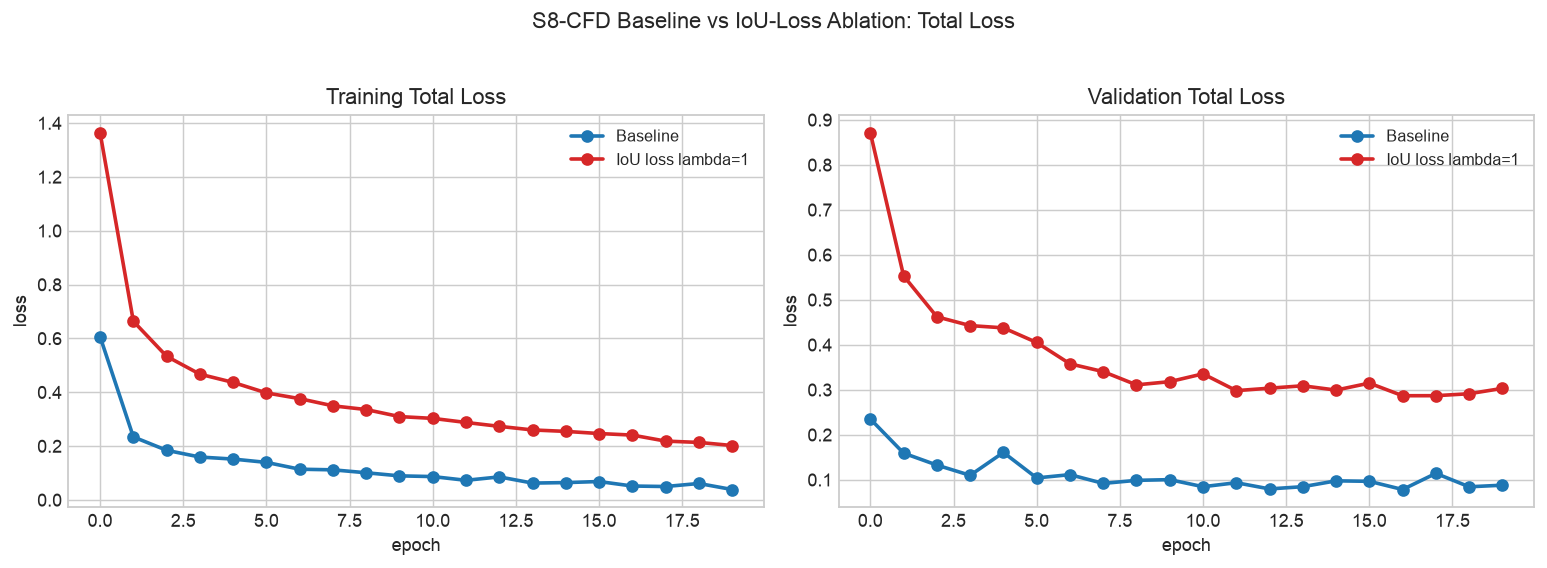

Saved reports/figures/detector_experiments_validation_loss_components.png and reports/figures/detector_experiments_validation_loss_components.pdf


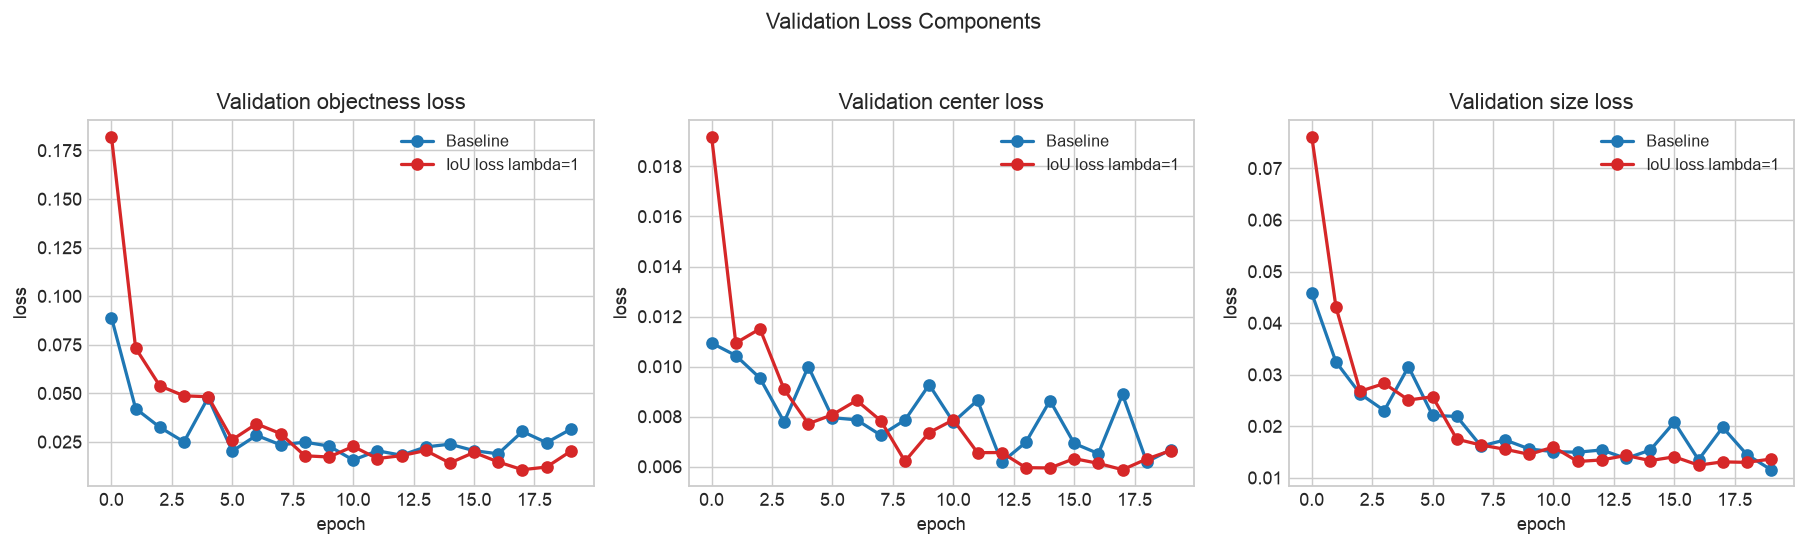

In [5]:
colors = {"Baseline": "#1f77b4", "IoU loss lambda=1": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for key, spec in EXPERIMENTS.items():
    history = artifacts[key]["history"]
    label = spec["label"]
    axes[0].plot(history["epoch"], history["train_total"], marker="o", linewidth=2, color=colors[label], label=label)
    axes[1].plot(history["epoch"], history["val_total"], marker="o", linewidth=2, color=colors[label], label=label)
axes[0].set_title("Training Total Loss")
axes[1].set_title("Validation Total Loss")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()
fig.suptitle("S8-CFD Baseline vs IoU-Loss Ablation: Total Loss", y=1.03)
fig.tight_layout()
save_figure(fig, "detector_experiments_training_total_loss")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.0), sharex=True)
components = [("objectness", "objectness"), ("center", "center"), ("size", "size")]
for ax, (title, suffix) in zip(axes, components):
    for key, spec in EXPERIMENTS.items():
        history = artifacts[key]["history"]
        label = spec["label"]
        ax.plot(history["epoch"], history[f"val_{suffix}"], marker="o", linewidth=1.8, color=colors[label], label=label)
    ax.set_title(f"Validation {title} loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()
fig.suptitle("Validation Loss Components", y=1.04)
fig.tight_layout()
save_figure(fig, "detector_experiments_validation_loss_components")
plt.show()


## 5. AP Curves

AP50, AP75, and mAP50-95 are plotted by epoch from the training history. The comparison is read-only and preserves the existing AP implementation and checkpoint-selection semantics.


Saved reports/figures/detector_experiments_validation_ap_curves.png and reports/figures/detector_experiments_validation_ap_curves.pdf


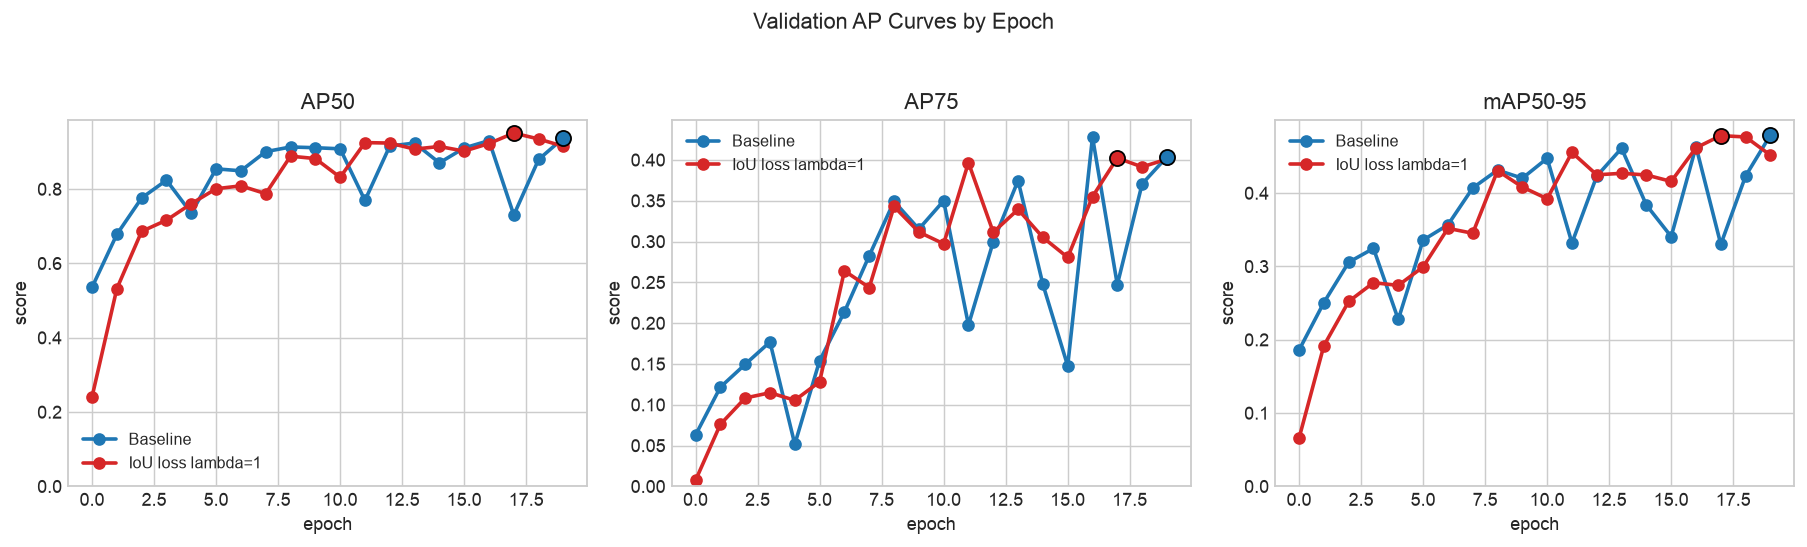

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.0), sharex=True, sharey=False)
ap_columns = [("val_ap50", "AP50"), ("val_ap75", "AP75"), ("val_map50_95", "mAP50-95")]
for ax, (column, title) in zip(axes, ap_columns):
    for key, spec in EXPERIMENTS.items():
        history = artifacts[key]["history"]
        label = spec["label"]
        ax.plot(history["epoch"], history[column], marker="o", linewidth=2, color=colors[label], label=label)
        best_epoch = int(artifacts[key]["best_checkpoint"]["best_epoch"])
        best_value = float(history.loc[history["epoch"] == best_epoch, column].iloc[0])
        ax.scatter([best_epoch], [best_value], s=70, color=colors[label], edgecolor="black", zorder=5)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("score")
    ax.set_ylim(bottom=0)
    ax.legend()
fig.suptitle("Validation AP Curves by Epoch", y=1.04)
fig.tight_layout()
save_figure(fig, "detector_experiments_validation_ap_curves")
plt.show()


## 6. IoU Loss Evolution

Only Experiment 1 logs `train_iou` and `val_iou`, because the frozen baseline did not include the optional IoU component. These curves verify the ablation term was active and tracked during training and validation.


Saved reports/figures/detector_experiments_iou_loss_evolution.png and reports/figures/detector_experiments_iou_loss_evolution.pdf


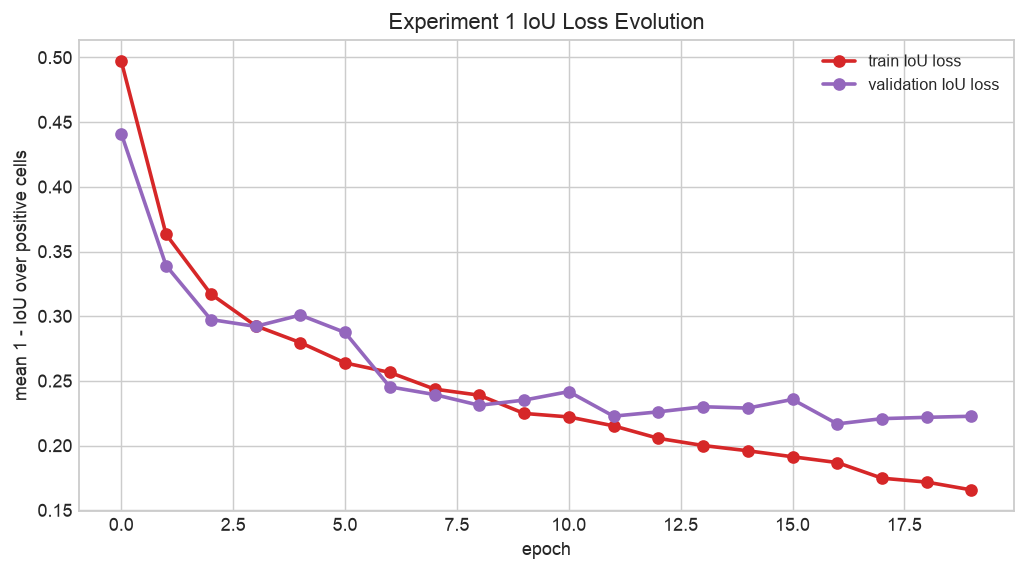

,epoch,train_iou,val_iou
0,0,0.497077,0.441068
1,1,0.363281,0.339157
2,2,0.317172,0.297426
3,3,0.292622,0.292120
4,4,0.279608,0.300856


,epoch,train_iou,val_iou
15,15,0.191332,0.235655
16,16,0.186826,0.216734
17,17,0.174757,0.220802
18,18,0.171746,0.221813
19,19,0.165679,0.222640


In [7]:
iou_history = artifacts["iou1"]["history"]
assert {"train_iou", "val_iou"}.issubset(iou_history.columns)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(iou_history["epoch"], iou_history["train_iou"], marker="o", linewidth=2, label="train IoU loss", color="#d62728")
ax.plot(iou_history["epoch"], iou_history["val_iou"], marker="o", linewidth=2, label="validation IoU loss", color="#9467bd")
ax.set_title("Experiment 1 IoU Loss Evolution")
ax.set_xlabel("epoch")
ax.set_ylabel("mean 1 - IoU over positive cells")
ax.legend()
fig.tight_layout()
save_figure(fig, "detector_experiments_iou_loss_evolution")
plt.show()

display(iou_history[["epoch", "train_iou", "val_iou"]].head())
display(iou_history[["epoch", "train_iou", "val_iou"]].tail())


## 7. Best Checkpoint Comparison

The predetermined selection metric was validation `mAP50-95`. On that criterion, the frozen baseline remains the selected model.


,experiment,best_epoch,AP50,AP75,mAP50-95,selected_threshold,precision,recall,F1,delta_vs_baseline
0,Baseline,19,0.937563,0.403768,0.479189,0.999,0.961123,0.908163,0.933893,0.000000
1,IoU loss lambda=1,17,0.950704,0.402293,0.478397,0.998,0.926148,0.946939,0.936428,-0.000792


Saved reports/figures/detector_experiments_best_checkpoint_comparison.png and reports/figures/detector_experiments_best_checkpoint_comparison.pdf


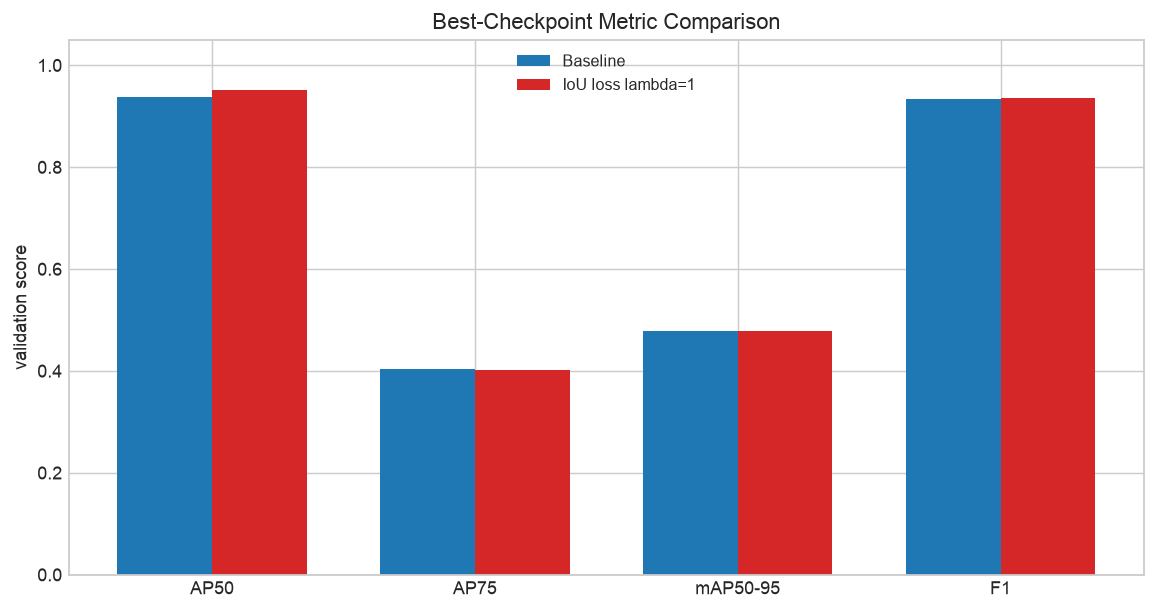

In [8]:
comparison = metrics_df.copy()
comparison["delta_vs_baseline"] = comparison["mAP50-95"] - float(comparison.loc[comparison["experiment"] == "Baseline", "mAP50-95"].iloc[0])
display(comparison)

plot_df = comparison.melt(
    id_vars="experiment",
    value_vars=["AP50", "AP75", "mAP50-95", "F1"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(plot_df["metric"].nunique())
width = 0.36
metrics_order = ["AP50", "AP75", "mAP50-95", "F1"]
for offset, experiment in [(-width / 2, "Baseline"), (width / 2, "IoU loss lambda=1")]:
    values = [float(plot_df[(plot_df["experiment"] == experiment) & (plot_df["metric"] == metric)]["score"].iloc[0]) for metric in metrics_order]
    ax.bar(x + offset, values, width=width, label=experiment, color=colors[experiment])
ax.set_xticks(x)
ax.set_xticklabels(metrics_order)
ax.set_ylabel("validation score")
ax.set_ylim(0, 1.05)
ax.set_title("Best-Checkpoint Metric Comparison")
ax.legend()
fig.tight_layout()
save_figure(fig, "detector_experiments_best_checkpoint_comparison")
plt.show()


## 8. Operating-Threshold Comparison

The selected operating threshold is derived from each experiment's validation threshold sweep by maximizing F1. Baseline final selection uses the refined confirmation sweep; its broad sweep is used for comparable threshold-curve plotting. This thresholded operating analysis is separate from ranked AP and was not used for checkpoint selection.

,experiment,selection_source,plot_source,plot_threshold_min,plot_threshold_max,selection_threshold_min,selection_threshold_max,selection_rows,selected_threshold,precision,recall,F1,predictions_per_image
0,Baseline,reports/experiments/baseline-s8-cfd-960-s8/thr...,reports/experiments/baseline-s8-cfd-960-s8/thr...,0.9,0.999,0.999,0.99995,20,0.999,0.961123,0.908163,0.933893,1.889796
1,IoU loss lambda=1,reports/experiments/ablation-iou1-s8-cfd-960-s...,reports/experiments/ablation-iou1-s8-cfd-960-s...,0.9,0.999,0.900,0.99900,100,0.998,0.926148,0.946939,0.936428,2.044898


Saved reports/figures/detector_experiments_operating_threshold_comparison.png and reports/figures/detector_experiments_operating_threshold_comparison.pdf


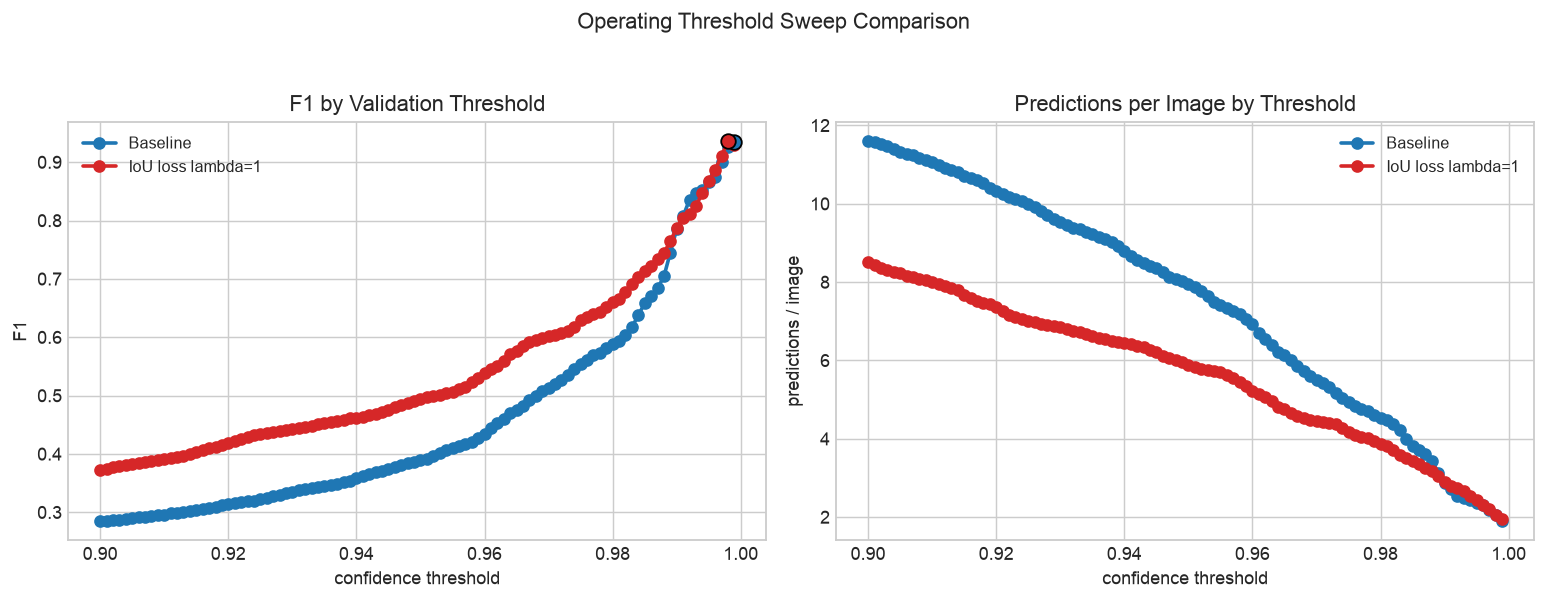

In [9]:
threshold_rows = []
for key, spec in EXPERIMENTS.items():
    selection_df = artifacts[key]["threshold"]
    plot_df = artifacts[key].get("threshold_broad", selection_df)
    best = best_threshold_row(selection_df)
    threshold_rows.append({
        "experiment": spec["label"],
        "selection_source": str((artifacts[key]["dir"] / "threshold" / "threshold_analysis.csv").relative_to(PROJECT_ROOT)),
        "plot_source": str(
            (artifacts[key]["dir"] / "threshold" / "broad" / "threshold_analysis.csv").relative_to(PROJECT_ROOT)
            if "threshold_broad" in artifacts[key]
            else (artifacts[key]["dir"] / "threshold" / "threshold_analysis.csv").relative_to(PROJECT_ROOT)
        ),
        "plot_threshold_min": plot_df["threshold"].min(),
        "plot_threshold_max": plot_df["threshold"].max(),
        "selection_threshold_min": selection_df["threshold"].min(),
        "selection_threshold_max": selection_df["threshold"].max(),
        "selection_rows": len(selection_df),
        "selected_threshold": best["threshold"],
        "precision": best["precision"],
        "recall": best["recall"],
        "F1": best["f1"],
        "predictions_per_image": best["predictions_per_image"],
    })
threshold_comparison_df = pd.DataFrame(threshold_rows)
display(threshold_comparison_df)

baseline_broad = artifacts["baseline"]["threshold_broad"]
baseline_broad_best = best_threshold_row(baseline_broad)
baseline_refined_best = best_threshold_row(artifacts["baseline"]["threshold"])
iou_threshold_best = best_threshold_row(artifacts["iou1"]["threshold"])
assert math.isclose(float(baseline_broad["threshold"].min()), 0.900, rel_tol=0, abs_tol=1e-12)
assert math.isclose(float(baseline_broad["threshold"].max()), 0.999, rel_tol=0, abs_tol=1e-12)
assert math.isclose(float(baseline_broad_best["threshold"]), 0.999, rel_tol=0, abs_tol=1e-12)
assert math.isclose(float(artifacts["baseline"]["threshold"]["threshold"].min()), 0.999, rel_tol=0, abs_tol=1e-12)
assert math.isclose(float(artifacts["baseline"]["threshold"]["threshold"].max()), 0.99995, rel_tol=0, abs_tol=1e-12)
assert math.isclose(float(baseline_refined_best["threshold"]), 0.999, rel_tol=0, abs_tol=1e-12)
assert math.isclose(float(iou_threshold_best["threshold"]), 0.998, rel_tol=0, abs_tol=1e-12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for key, spec in EXPERIMENTS.items():
    threshold_df = artifacts[key].get("threshold_broad", artifacts[key]["threshold"])
    label = spec["label"]
    best = best_threshold_row(artifacts[key]["threshold"])
    axes[0].plot(threshold_df["threshold"], threshold_df["f1"], marker="o", linewidth=2, label=label, color=colors[label])
    axes[0].scatter([best["threshold"]], [best["f1"]], s=65, color=colors[label], edgecolor="black", zorder=5)
    axes[1].plot(threshold_df["threshold"], threshold_df["predictions_per_image"], marker="o", linewidth=2, label=label, color=colors[label])
axes[0].set_title("F1 by Validation Threshold")
axes[0].set_xlabel("confidence threshold")
axes[0].set_ylabel("F1")
axes[1].set_title("Predictions per Image by Threshold")
axes[1].set_xlabel("confidence threshold")
axes[1].set_ylabel("predictions / image")
for ax in axes:
    ax.legend()
fig.suptitle("Operating Threshold Sweep Comparison", y=1.04)
fig.tight_layout()
save_figure(fig, "detector_experiments_operating_threshold_comparison")
plt.show()

## 9. Interpretation

Experiment 1 is a useful neutral/negative ablation. Adding standard IoU loss with `lambda_iou=1.0` improved AP50 and slightly improved the validation-selected operating F1, but it did not improve AP75 and did not improve the predetermined primary metric, validation `mAP50-95`. The mAP difference is extremely small and comes from one seed, so it should not be treated as strong evidence of general superiority.

The result does not demonstrate improved strict localization over the frozen baseline. Because validation `mAP50-95` was the predetermined model-selection metric, final model selection remains the baseline checkpoint.


## 10. Limitations

This comparison uses one seed and a single IoU-loss weight. It evaluates validation artifacts only and does not use the sealed test split. The result should be treated as controlled ablation evidence, not as a broad hyperparameter conclusion.

Future work may consider LR scheduling, higher input resolution, focal-style objectness weighting, or generalized IoU-family losses, but those are outside this notebook and are not run here.
